# Compute ACFs
Compute
$$
C_u(t) = \frac{\langle \delta u(0)\delta u(t)\rangle}{\langle \delta u(0)^2\rangle} \quad t\in[0, T]
$$
with $u$ = 
1. $s_1 = \psi_1(x)$
2. $s_2 = \psi_2(x)$
3. diheral, $\phi$
4. diheral, $\psi$

Rules of Thumb for procecss with timescale $\tau_u$ (we are computing it, but I've written in into the exponential as the "true" timescale):
$$
\tau_u = \int_0^\infty dt,\ e^{-t/\tau_u} 
\approx \int_0^{c\tau_u} dt,\ e^{-t/\tau_u}
$$
1. Sokal window constant (c) = how many timescales out to capture this integral.  Sweet spot = 5 where 99.3% of the ACF is captured.  There is a bias-variance tradeoff.
2. ACF horizon
$$
T \ge 2c\tau_u \quad \textrm{go to 15 ns }\approx 10\tau_1
$$

## Load unbiased dataset

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from src.data import simulation_data
from src.param import param_unbiased_reference

# from src.grid2d import ranges_data, grid1d_from_range, hist2d
# from src.plots import plot_dihedrals_hist2d
# from src.plots import plot_cvs_hist2d

p = param_unbiased_reference()
sd = simulation_data(p)
# print(f"cvs data ranges = {ranges_data(sd.cvs, pad=0.25)}")

# x = grid1d_from_range([-2, 7.6])
# y = grid1d_from_range([-1.4, 2.2])
# # p = hist2d(x, y, sd.cvs)

# fig, axs = plt.subplots(1, 2, figsize=(7, 3))
# plot_dihedrals_hist2d(fig, axs[0], sd.dihedrals)
# plot_cvs_hist2d(fig, axs[1], x, y, sd.cvs)
# fig.tight_layout()

## Compute the ACFs

In [4]:
sd.cvs.shape

(3000000, 2)

[warn] Sokal window never closed; using the full series (tau may be tail-contaminated). Use a longer trajectory or a smaller c_window.
[warn] Sokal window never closed; using the full series (tau may be tail-contaminated). Use a longer trajectory or a smaller c_window.


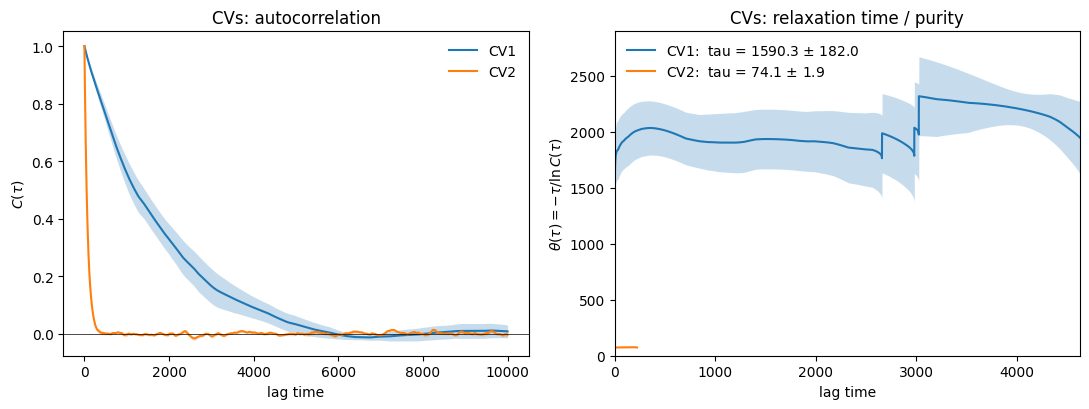

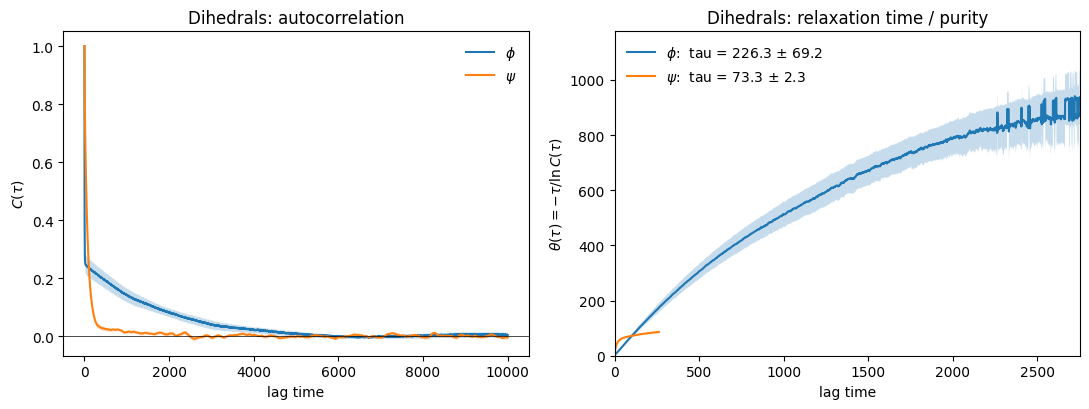

   CV1:  tau =  1590.30 +/- 182.02
   CV2:  tau =    74.09 +/- 1.95
$\phi$:  tau =   226.31 +/- 69.18
$\psi$:  tau =    73.31 +/- 2.34


In [7]:
from src.acf import compute_acf_with_errors  # the patched module

# --- settings -------------------------------------------------------------
LAGTIME = sd.lagtime  # time between frames (ps)
NUM_FRAMES_ACF = 10_000  # how many lags to compute
NUM_BLOCKS = 8  # contiguous blocks -> standard error of the mean


def analyze(
    signals,
    kind,
    title,
    lagtime=LAGTIME,
    num_frames_acf=NUM_FRAMES_ACF,
    num_blocks=NUM_BLOCKS,
    c_floor=0.05,
):
    """Blocked ACF / theta analysis on {label: trajectory}, with a 2-panel plot.

    signals : dict {label: 1-D array}.  For kind='circular' the arrays are
              angles in *radians*.
    kind    : 'linear' (unbounded CVs) or 'circular' (dihedrals).
    c_floor : only show theta while C(tau) > c_floor; past that the ACF is noise
              and theta = -tau/ln C diverges meaninglessly.
    """
    results = {
        lab: compute_acf_with_errors(
            u, lagtime, num_frames_acf, num_blocks=num_blocks, kind=kind
        )
        for lab, u in signals.items()
    }

    fig, (axC, axT) = plt.subplots(1, 2, figsize=(11, 4.2))
    colors = plt.cm.tab10.colors
    th_vals, xmax = [], 0.0

    for (label, r), c in zip(results.items(), colors):
        t = r["time"]
        # C(tau) with +/- 1 SEM band
        axC.plot(t, r["ct_mean"], color=c, lw=1.5, label=label)
        axC.fill_between(
            t,
            r["ct_mean"] - r["ct_err"],
            r["ct_mean"] + r["ct_err"],
            color=c,
            alpha=0.25,
            lw=0,
        )
        # theta(tau) with +/- 1 SEM band, restricted to where C > c_floor
        ok = np.isfinite(r["theta_mean"]) & (r["ct_mean"] > c_floor)
        th = np.where(ok, r["theta_mean"], np.nan)
        the = np.where(ok, r["theta_err"], np.nan)
        axT.plot(
            t,
            th,
            color=c,
            lw=1.5,
            label=f"{label}:  tau = {r['tau_mean']:.1f} $\\pm$ {r['tau_err']:.1f}",
        )
        axT.fill_between(t, th - the, th + the, color=c, alpha=0.25, lw=0)
        if ok.any():
            th_vals.append(th[ok])
            xmax = max(xmax, t[ok].max())

    axC.axhline(0, color="k", lw=0.5)
    axC.set_xlabel("lag time")
    axC.set_ylabel(r"$C(\tau)$")
    axC.set_title(f"{title}: autocorrelation")
    axC.legend(frameon=False)
    axT.set_xlabel("lag time")
    axT.set_ylabel(r"$\theta(\tau) = -\tau/\ln C(\tau)$")
    axT.set_title(f"{title}: relaxation time / purity")
    axT.legend(frameon=False)
    if th_vals:
        axT.set_xlim(0, xmax)
        axT.set_ylim(0, 1.25 * np.nanmax(np.concatenate(th_vals)))
    fig.tight_layout()
    return fig, results


# 1-2.  Linear CVs:  CV1 = sd.cvs[:, 0], CV2 = sd.cvs[:, 1] -------------------
cv_signals = {"CV1": sd.cvs[:, 0], "CV2": sd.cvs[:, 1]}
fig_cv, res_cv = analyze(cv_signals, kind="linear", title="CVs")
fig_cv.savefig("acf_cvs.png", dpi=150)

# 3.  Dihedrals (circular):  phi, psi  -- MUST be radians --------------------
phi, psi = sd.dihedrals[:, 0], sd.dihedrals[:, 1]
# if your dihedrals are in degrees, convert first:
# phi, psi = np.deg2rad(phi), np.deg2rad(psi)
dih_signals = {r"$\phi$": phi, r"$\psi$": psi}
fig_dih, res_dih = analyze(dih_signals, kind="circular", title="Dihedrals")
fig_dih.savefig("acf_dihedrals.png", dpi=150)

plt.show()

for name, r in {**res_cv, **res_dih}.items():
    print(f"{name:>6}:  tau = {r['tau_mean']:8.2f} +/- {r['tau_err']:.2f}")

In [8]:
sd.timescales

array([1.25255696e+03, 6.11525847e+01, 2.63525642e+01, 2.30529580e+00,
       1.52031536e+00, 1.16611866e+00])

In [ ]:
from src.acf import compute_acf_with_errors
from src.acf import compute_acf_original

# choose 15 ns "ACF horizon" to capture 10 tau_1's
num_frames_acf = int(15 / p.ns_per_frame)

acf = {}
acf["FFT"] = compute_acf_with_errors(
    sd.cvs[:, 0], p.ns_per_frame, num_frames_acf, kind="linear"
)
tau, ct = compute_acf_original(sd.cvs[:, 0], p.ns_per_frame, num_frames_acf)
# acf['Original'] = {'time': acf['FFT']['time']}

In [ ]:
acf['Original'] = {'time': acf['FFT']['time'], ct

(15000,)

In [14]:
tau

np.float64(1.050430258272731)

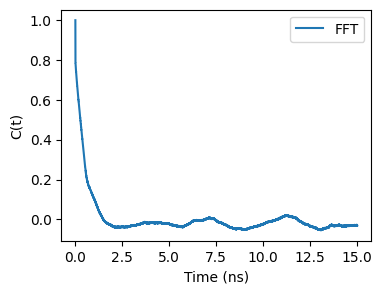

In [ ]:
def plot_acf_curve(ax, acf, label):
    ax.plot(acf["time"], c["ct_mean"], label=label)
    # ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=5, elinewidth=1.5, alpha=0.02)


fig, ax = plt.subplots(1, 1, figsize=(4, 3))
plot_acf_curve(ax, acf["s1"], "FFT")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("C(t)")
ax.legend()

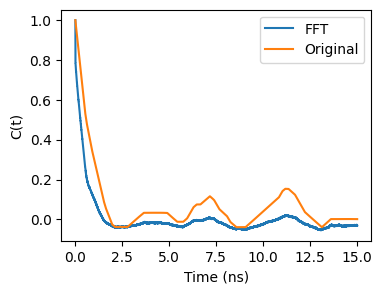

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

c = acf["s1"]
x = c["time"]
y = c["ct_mean"]
yerr = c["ct_err"]

# ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=5, elinewidth=1.5, alpha=0.02)
ax.plot(x, y, label="FFT")
ax.plot(x, ct, label="Original")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("C(t)")
ax.legend()

Text(0, 0.5, 's(t)')

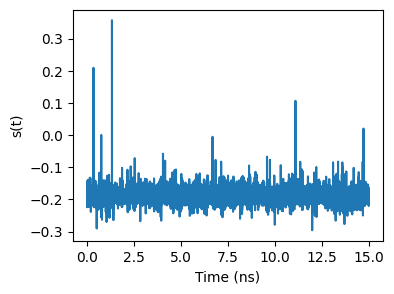

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

x = c["time"]
y = sd.cvs[:, 0][: len(x)]

ax.plot(x, y)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("s(t)")

In [ ]:
x.shape, y.shape, yerr.shape

((15000,), (15000,), (15000,))

In [ ]:
from src.dataclass import DataClass, data_class, numpy_ndarray

kT = kT_in_kJ_per_mol(p.temperature)